# Basic Supply and Demand Models

In economics, supply and demand are fundamental concepts that describe how prices and quantities of are determined in a market.

In this notebook we'll explore what happens if _all_ companies shift their behavior simultaneously. That is, we'll examine the effect of an innovation that is introduced to all companies at the same time.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.append("..")
from src import plots

In [2]:
# print(plt.style.available)
plt.style.use(["seaborn-v0_8", "seaborn-v0_8-darkgrid", "seaborn-v0_8-notebook"])

## Supply and Demand Curves

### Demand Curve

The **demand curve** represents the relationship between the price of a good and the quantity demanded by consumers. It typically slopes downward, indicating that as the price increases, the quantity demanded decreases, and vice versa.

An **isoelastic** (constant price elasticity) demand curve can be written as:
$$ P = k Q^{-1/\varepsilon} $$
Where:

- $ P $ is the price of the good.
- $ Q $ is the quantity demanded.
- $ \varepsilon $ is the price elasticity parameter.

**Note:** The price elasticity of demand is defined as the percentage change in quantity demanded divided by the percentage change in price. Since usually demand decreases as price increases, the price elasticity of demand is typically negative. For simplicity, we add a negative sign to the exponent and use a positive value for $ \varepsilon $.

Important observations about this isoelastic demand curve:

1. The curve is downward sloping, meaning that as the price increases, the quantity demanded decreases.
1. Higher values of $ \varepsilon $ produce a more convex curve, reflecting greater consumer responsiveness to price changes near the intercepts.

This demand curve can be constrained with a maximum quantity, $ Q_{\text{max}} $, to reflect real-world limitations on demand and a maximum price, $ P_{\text{max}} $, to reflect the highest price consumers are willing to pay.

$$
P = \begin{cases}
k Q^{-1/\varepsilon} & \text{if }Q \geq Q_{\text{min}} \text{ and } Q \leq Q_{\text{max}} \\
P_{\text{max}} & \text{if }Q < Q_{\text{min}} \\
0 & \text{if }Q > Q_{\text{max}}
\end{cases}
$$

where $Q_{\text{min}}$ is the quantity at which the price reaches its maximum. That is:
$$
P_{\text{max}} = k Q_{\text{min}}^{-1/\varepsilon}
$$


In [3]:
def price_at_demand_iso(q, max_price, max_quant, epsilon=1.0, k=0.01):
    # Explicitly handle the case when q is zero or negative to avoid warnings
    power = np.power(q, -1 / epsilon, out=np.zeros_like(q), where=q > 0)
    computed_values = k * power
    computed_values[q <= 0] = max_price
    computed_values[q > max_quant] = 0
    computed_values[computed_values > max_price] = max_price
    return computed_values

def price_at_demand_linear(q, max_price, max_quant):
    slope = max_price / max_quant
    computed_values = max_price - slope * q
    computed_values[q < 0] = max_price
    computed_values[q > max_quant] = 0
    computed_values[computed_values < 0] = 0
    return computed_values

In [4]:
settings_demand = {
    "max_price": 1,
    "max_quant": 1,
    "epsilon": 1.3,
    "k": .2,
}

In [5]:
q_values = np.linspace(
    0, 1.1 * settings_demand["max_quant"], 200
)
p_values = price_at_demand_iso(q_values, **settings_demand)

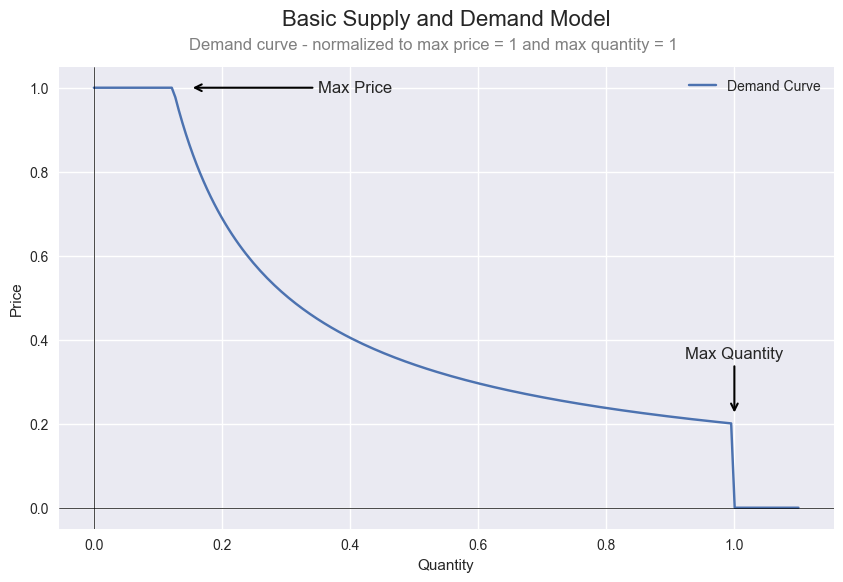

In [6]:
max_price = settings_demand["max_price"]
max_quant = settings_demand["max_quant"]

plt.figure(figsize=(10, 6))
plt.plot(q_values, p_values, label="Demand Curve")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Basic Supply and Demand Model", fontsize=16, pad=30)
plt.suptitle(
    "Demand curve - normalized to max price = 1 and max quantity = 1",
    fontsize=12,
    y=0.93,
    color="gray",
)
plt.legend()
# show horizontal and vertical lines at the p = 0 and q = 0 axes
plt.axhline(0, color="black", lw=0.5)
plt.axvline(0, color="black", lw=0.5)

# Annotate max price with a horizontal arrow pointing to the y-axis intercept
plt.annotate(
    f"Max Price",
    xy=(0.15, max_price),
    xytext=(0.35 * max_quant, max_price),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    fontsize=12,
    va="center",
    ha="left",
)

# Annotate max quantity with a vertical arrow pointing to the x-axis intercept
plt.annotate(
    f"Max Quantity",
    xy=(max_quant, 0.22),
    xytext=(max_quant, 0.35 * max_price),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    fontsize=12,
    ha="center",
    va="bottom",
)

plt.show()

## Revenue as a Function of Quantity

Revenue is calculated as the price multiplied by the quantity sold.
This means that we can express revenue as a function of quantity using the demand curve.

Over the range where elasticity is constant (where neither price nor quantity is capped), revenue is strictly increasing
or srictly decreasing depending on the value of $ \varepsilon $:
- If $ \varepsilon > 1 $, revenue is strictly increasing with quantity, meaning that as more units are sold, total revenue increases.
- If $ \varepsilon < 1 $, revenue is strictly decreasing with quantity, meaning that as more units are sold, total revenue decreases.

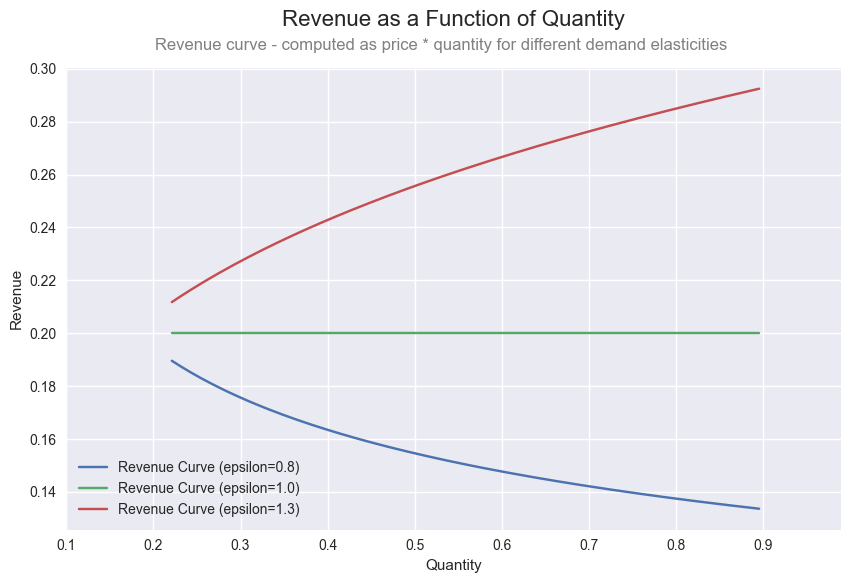

In [7]:
r_values_array = []
eps_values = [0.8, 1.0, 1.3]
k_values = [0.13, 0.2, 0.3]
for i, eps in enumerate(eps_values):
    _settings = settings_demand.copy()
    _settings["epsilon"] = eps
    _settings["k"] = k_values[i]
    p_values = price_at_demand_iso(q_values, **_settings)
    r_values = p_values * q_values
    r_values = np.where((q_values < 0.22) | (q_values > 0.9), np.nan, r_values)
    r_values_array.append(r_values)


plt.figure(figsize=(10, 6))
for eps, r_values in zip(eps_values, r_values_array):
    plt.plot(q_values, r_values, label=f"Revenue Curve (epsilon={eps})")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Revenue as a Function of Quantity", fontsize=16, pad=30)
plt.suptitle(
    "Revenue curve - computed as price * quantity for different demand elasticities",
    fontsize=12,
    y=0.93,
    color="gray",
)
plt.legend(loc="lower left")
plt.xlim(0.1, 0.99)
plt.show()

## The effect of an increase in supply


In [8]:
def price_at_supply(q, min_price, max_quant, epsilon=1.0, k=0.2):
    power = np.power(q, 1 / epsilon, out=np.zeros_like(q), where=q > 0)
    computed_values = k * power
    computed_values[q < 0] = 0
    computed_values[q > max_quant] =computed_values[q <= max_quant].max()
    computed_values[computed_values < min_price] = min_price

    return computed_values

In [9]:
settings_supply = {
    "min_price": 0.1,
    "max_quant": 1,
    "epsilon": 0.5,
    "k": 1,
}

In [10]:
def find_equilibrium(demand_settings, supply_settings):
    q_values = np.linspace(0, demand_settings["max_quant"], 10000)
    p_demand = price_at_demand_iso(q_values, **demand_settings)
    p_supply = price_at_supply(q_values, **supply_settings)
    equilibrium_index = np.argwhere(np.isclose(p_demand, p_supply, atol=1e-4)).flatten()
    if len(equilibrium_index) == 0:
        return 0, 0
    equilibrium_q = q_values[equilibrium_index[0]]
    equilibrium_p = p_demand[equilibrium_index[0]]
    return equilibrium_q, equilibrium_p

In [11]:
s_values = price_at_supply(q_values, **settings_supply)
settings_efficient = settings_supply.copy()
settings_efficient["max_quant"] *= 1.2
settings_efficient["min_price"] *= 0.8
settings_efficient["k"] *= 0.7
s_efficient_values = price_at_supply(q_values, **settings_efficient)
p_values = price_at_demand_iso(q_values, **settings_demand)

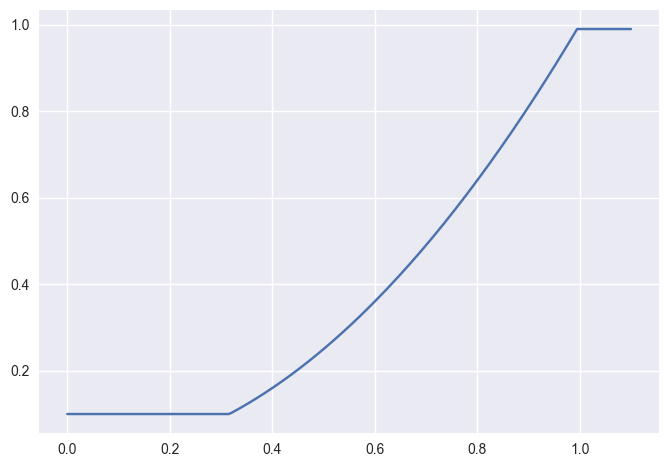

In [12]:
plt.plot(q_values, s_values, label="Supply Curve")

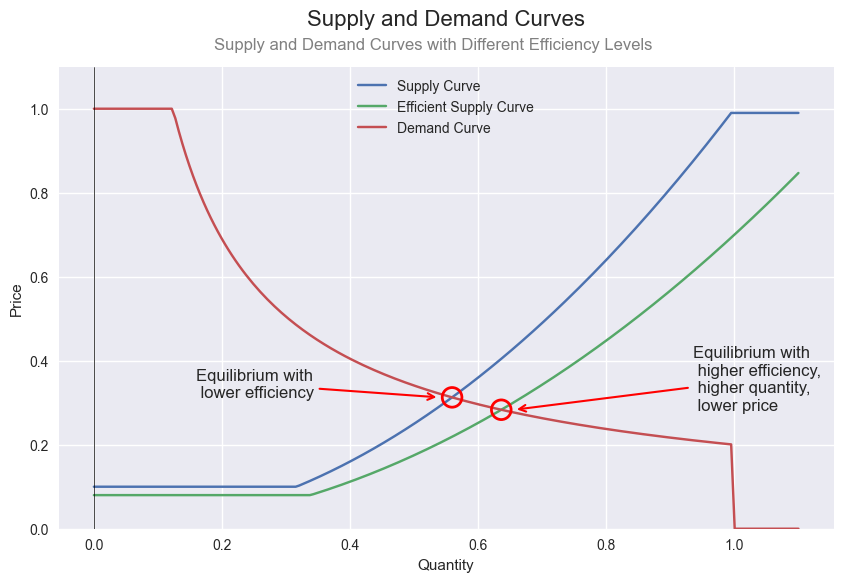

In [13]:
# Find equilibrium points
eq_q, eq_p = find_equilibrium(settings_demand, settings_supply)
eq_q_eff, eq_p_eff = find_equilibrium(settings_demand, settings_efficient)

# Pull colors from the theme's prop cycle
theme_colors = [c["color"] for c in plt.rcParams["axes.prop_cycle"]]
c_supply, c_supply_eff, c_demand = theme_colors[0], theme_colors[1], theme_colors[2]


fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))


ax1.plot(q_values, s_values, label="Supply Curve", color=c_supply)
ax1.plot(
    q_values, s_efficient_values, label="Efficient Supply Curve", color=c_supply_eff
)
ax1.plot(q_values, p_values, label="Demand Curve", color=c_demand)

# Annotate equilibrium points
ax1.scatter(
    [eq_q, eq_q_eff],
    [eq_p, eq_p_eff],
    zorder=5,
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
)
ax1.annotate(
    f"Equilibrium with\n lower efficiency",
    xy=(eq_q - 0.02, eq_p),
    xytext=(eq_q - 0.4, eq_p),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=12,
)
ax1.annotate(
    f"Equilibrium with\n higher efficiency,\n higher quantity,\n lower price",
    xy=(eq_q_eff + 0.02, eq_p_eff),
    xytext=(eq_q_eff + 0.3, eq_p_eff),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=12,
)

ax1.set_xlabel("Quantity")
ax1.set_ylabel("Price")
ax1.set_title("Supply and Demand Curves", fontsize=16, pad=30)
plt.suptitle(
    "Supply and Demand Curves with Different Efficiency Levels",
    fontsize=12,
    y=0.93,
    color="gray",
)
ax1.legend()
# show horizontal and vertical lines at the p = 0 and q = 0 axes
ax1.axhline(0, color="black", lw=0.5)
ax1.axvline(0, color="black", lw=0.5)
ax1.set_ylim((0, 1.1))

plt.show()

## Profit vs Cost reduction

Whether cost reduction leads to increased profits depends on the price elasticity of demand for the product.
If elasticity is greater than 1, then cost reduction can lead to increased profits. But by how much?

Revenue is given by:
$$ R = P \cdot Q $$

assume a profit margin of m%, then the profit is given by:
$$ p = m \cdot P \cdot Q $$

if costs are reduced by a factor of r, then the new revenue is given by:

$$ R'/R = 1 - (1+E)r $$

and the new profit is given by:
$$ p'/p = 1 - (1+E)r $$


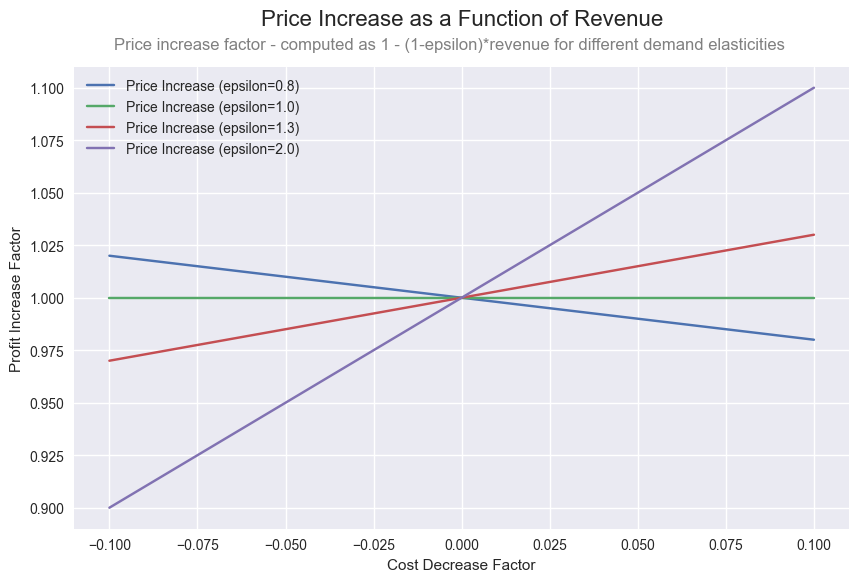

In [14]:
m = 0.1
eps_values = [0.8, 1.0, 1.3, 2.0]
r_values_array = np.linspace(-0.1, 0.1, 100)
pr_inc_values_array = []
pr_increase_const_price_array = []
for eps in eps_values:
    pr_inc_values = 1 - (1 - eps) * r_values_array
    pr_inc_values_array.append(pr_inc_values)
    pr_inc_const_price_values = r_values_array / m
    pr_increase_const_price_array.append(pr_inc_const_price_values)

plt.figure(figsize=(10, 6))
for eps, pr_inc_values in zip(eps_values, pr_inc_values_array):
    plt.plot(r_values_array, pr_inc_values, label=f"Price Increase (epsilon={eps:.1f})")
plt.xlabel("Cost Decrease Factor")
plt.ylabel("Profit Increase Factor")
plt.title("Price Increase as a Function of Revenue", fontsize=16, pad=30)
plt.suptitle(
    "Price increase factor - computed as 1 - (1-epsilon)*revenue for different demand elasticities",
    fontsize=12,
    y=0.93,
    color="gray",
)
plt.legend()